In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict
import random
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


import importlib
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import A2C
import matplotlib.pyplot as plt
import torch

# Import as module
import environment.users.citation_users_loader as citation_users_loader
importlib.reload(citation_users_loader)

import environment.citations.citation_selector as citation_selector
importlib.reload(citation_selector)

import environment.citation_reward_shaping as citation_reward_shaping
importlib.reload(citation_reward_shaping)

import environment.citations.citation as citation
importlib.reload(citation)

import environment.users.citation_user as citation_user
importlib.reload(citation_user)

import environment.citations.citation_loader as citation_loader
importlib.reload(citation_loader)

import environment.citation_memory as citation_memory
importlib.reload(citation_memory)

import environment.users.user_rater as user_rater
importlib.reload(user_rater)

import environment.user_env as user_env
importlib.reload(user_env)

from environment.user_env import UserEnv
from environment.users.citation_users_loader import CitationUsersLoader
from environment.citations.citation_loader import CitationsLoader
from environment.citations.citation import Citation
from environment.citations.citation_selector import CitationsSelector
from environment.citation_memory import CitationMemory
from environment.users.citation_user import CitationUser
from environment.users.user_rater import RuleBasedCitationRater
from environment.citation_reward_shaping import CitationRewardReshapingExpDecay


from stable_baselines3 import DQN
from stable_baselines3 import A2C
from stable_baselines3 import PPO


In [2]:
paper_loader = CitationsLoader("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
eval_users_loader = CitationUsersLoader("../environment/users/datasets/users_relevance_threshold.json")
all_users = eval_users_loader.get_users()

reward_shaping = CitationRewardReshapingExpDecay()
selector = CitationsSelector()

env = UserEnv(
        render_mode= "human",
        debug=False,
        items_loader=paper_loader,
        user_list=all_users,
        items_selector=selector,
        reward_shaping=reward_shaping,
        max_interactions=200,  # <- Match what the model was trained on
        render_path="./tmp/render/",
)
env = Monitor(env, filename=f"A2C150000_alluser_random", info_keywords=("user_id", "item_interact", "item_clicks"))
model = A2C.load("models/A2C_citation_recommender_baseline_150000", env=env, device="cpu")

Wrapping the env in a DummyVecEnv.


In [5]:
import numpy as np
K=10
def recommend_k_paper(env, agent, K=10, num_users=5):
    # rec = {}
    infos = {}
    for user_idx in range(num_users):
        obs, info = env.reset(user_id=user_idx)
        # print(obs)
        done = False
        
        user_id = info['user_id']
        
        recommended_items = list()
        while len(recommended_items) < K:
            obs = {k: np.array([v]) for k, v in obs.items()}
            action, _ = agent.predict(obs)
            action = int(action)
            recommended_items.append(action)
        
            obs, _, done, _, info = env.step(action)
            infos[user_id] = info
            if done:
                obs, info = env.reset(user_id=user_idx)

    return infos


# Simulate user clicks
def simulate_user_clicks(model, env=env, K=K, all_users=all_users):
    recommended_papers = []
    history_for_all_sessions= []
    for _ in range(10):
        print(_)
        infos = recommend_k_paper(env, model, K=K, num_users=len(all_users))
        # recommended_papers.append(recs)
        history = {}
        papers ={}

        for user_id, info in infos.items():
            user = [i for i in all_users if i.id == user_id][0]
            history[user_id] = info['item_clicks']
            papers[user_id] = info['item_interact']
        history_for_all_sessions.append(history)
        recommended_papers.append(papers)

    return recommended_papers, history_for_all_sessions


reccommended_papers, history_for_all_sessions = simulate_user_clicks(model)
history_for_all_sessions

0
Final score: (1 + 0.24333333333333335 + 0.9494949494949495) / 3 = 0.730942760942761
user = 0 - action = 10798 - rating = 0.730942760942761 - click = 1 - interact_num = 1 - reward = 1.461885521885522
Final score: (0.6114400810510001 + 0.4133333333333334 + 0.75) / 3 = 0.5915911381281111
user = 0 - action = 33017 - rating = 0.5915911381281111 - click = 1 - interact_num = 2 - reward = -0.3316817723743778
Final score: (0.6483755294633327 + 0.4133333333333334 + 0.9078282828282829) / 3 = 0.656512381874983
user = 0 - action = 19649 - rating = 0.656512381874983 - click = 1 - interact_num = 1 - reward = 1.313024763749966
Final score: (0.1407983399484145 + 0 + 0) / 3 = 0.04693277998280484
user = 0 - action = 33347 - rating = 0.04693277998280484 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.657696483104302 + 0.2733333333333333 + 0.952020202020202) / 3 = 0.6276833394859458


/var/folders/_f/s0xx4_bj711c1h8k9b5vjhgm0000gn/T/ipykernel_87846/2435250870.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  action = int(action)


user = 0 - action = 10117 - rating = 0.6276833394859458 - click = 1 - interact_num = 1 - reward = 1.2553666789718916
Final score: (0.6549553889644235 + 0.64 + 0.875) / 3 = 0.7233184629881412
user = 0 - action = 8873 - rating = 0.7233184629881412 - click = 1 - interact_num = 1 - reward = 1.4466369259762824
Final score: (1 + 0.5333333333333334 + 0.9078282828282829) / 3 = 0.8137205387205387
user = 0 - action = 21729 - rating = 0.8137205387205387 - click = 1 - interact_num = 1 - reward = 1.6274410774410775
Final score: (0.47049037031244145 + 0 + 0) / 3 = 0.15683012343748048
user = 0 - action = 39527 - rating = 0.15683012343748048 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.6539866081252272 + 0.64 + 0.75) / 3 = 0.6813288693750758
user = 0 - action = 18257 - rating = 0.6813288693750758 - click = 1 - interact_num = 1 - reward = 1.3626577387501515
Final score: (0.6589308344511637 + 0.48666666666666675 + 0.9166666666666667) / 3 = 0.6874213892614991
user = 0 - action = 19177 -

[{0: (1, 1, 1, 0, 1, 1, 1, 0, 1, 1),
  1: (1, 1, 1, 0, 0, 1, 1, 1, 1, 1),
  2: (1, 0, 0, 0, 1, 0, 0, 0, 1, 1),
  3: (1, 1, 1, 1, 1, 0, 0, 0, 0, 1),
  4: (0, 1, 1, 0, 0, 0, 1, 1, 0, 1),
  5: (1, 0, 1, 1, 0, 1, 1, 0, 1, 0),
  6: (0, 0, 1, 0, 1, 1, 1, 1, 1, 1),
  7: (1, 1, 0, 1, 1, 1, 0, 1, 0, 0),
  8: (1, 1, 0, 0, 0, 0, 0, 0, 0, 0)},
 {0: (1, 0, 1, 0, 1, 1, 0, 0, 1, 0),
  1: (1, 1, 0, 1, 1, 1, 0, 1, 1, 0),
  2: (1, 1, 1, 1, 1, 1, 1, 1, 0, 1),
  3: (1, 0, 1, 0, 0, 0, 1, 1, 1, 1),
  4: (1, 1, 1, 1, 1, 1, 0, 0, 1, 0),
  5: (0, 0, 1, 1, 0, 1, 1, 1, 1, 1),
  6: (1, 0, 1, 1, 0, 1, 0, 0, 0, 1),
  7: (0, 0, 1, 0, 0, 0, 0, 0, 0, 1),
  8: (0, 0, 1, 0, 0, 0, 1, 0, 0, 1)},
 {0: (0, 1, 0, 1, 0, 0, 1, 1, 0, 1),
  1: (1, 1, 0, 1, 1, 1, 1, 0, 0, 0),
  2: (1, 1, 1, 1, 1, 1, 1, 1, 1, 1),
  3: (0, 0, 0, 1, 0, 0, 0, 1, 0, 1),
  4: (0, 1, 0, 0, 0, 0, 1, 1, 0, 1),
  5: (1, 0, 1, 1, 0, 0, 1, 1, 1, 0),
  6: (1, 1, 1, 1, 1, 1, 1, 1, 0, 0),
  7: (1, 1, 0, 1, 1, 1, 1, 1, 0, 0),
  8: (0, 0, 1, 1, 1, 0, 1, 0, 0, 1)}

In [18]:
reccommended_papers

[{0: (10798, 33017, 19649, 33347, 10117, 8873, 21729, 39527, 18257, 19177),
  1: (47409, 20093, 10782, 33181, 36209, 10086, 34761, 1822, 2027, 5434),
  2: (20398, 41672, 41781, 45811, 5148, 29853, 33826, 35394, 13200, 16698),
  3: (38549, 8997, 9977, 25131, 6899, 46012, 41756, 46717, 27851, 9446),
  4: (26748, 45173, 8953, 34705, 46227, 45519, 25126, 32338, 40112, 1215),
  5: (31668, 20769, 378, 4368, 1161, 41120, 37660, 33746, 34297, 38287),
  6: (43555, 31573, 18941, 45973, 37043, 2880, 212, 483, 8330, 37119),
  7: (26313, 2723, 32803, 21473, 28472, 5389, 41655, 13166, 34040, 34611),
  8: (29107, 59, 43294, 48826, 38580, 38626, 42394, 47913, 46338, 50025)},
 {0: (5920, 41147, 17962, 41358, 6832, 31864, 19922, 40283, 15618, 16588),
  1: (17112, 15420, 40415, 7241, 16123, 25931, 48868, 5181, 4830, 24281),
  2: (40987, 25893, 49415, 19046, 8248, 9940, 1424, 9350, 34427, 9217),
  3: (27609, 36530, 24863, 39355, 32972, 45379, 17597, 2683, 19907, 14272),
  4: (47565, 36062, 26080, 36102, 2

A2C


,User,Precision per Session,Mean Precision,Cumulative Hit History
0,0,"[0.8, 0.5, 0.5, 0.5, 0.2, 0.5, 0.5, 0.4, 0.8, ...",0.54,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,1,"[0.8, 0.7, 0.6, 0.7, 1.0, 0.7, 0.7, 0.9, 0.5, ...",0.71,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
2,2,"[0.4, 0.9, 1.0, 0.7, 0.6, 0.8, 0.8, 0.7, 0.8, ...",0.73,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
3,3,"[0.6, 0.6, 0.3, 0.7, 0.3, 0.8, 0.8, 0.7, 0.3, ...",0.60,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
4,4,"[0.5, 0.7, 0.4, 0.3, 0.7, 0.7, 0.5, 0.7, 0.9, ...",0.63,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
5,5,"[0.6, 0.7, 0.6, 0.7, 0.5, 0.7, 0.8, 0.6, 0.6, ...",0.65,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
6,6,"[0.7, 0.5, 0.8, 0.6, 0.7, 0.4, 0.6, 0.7, 0.6, ...",0.63,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
7,7,"[0.6, 0.2, 0.7, 0.4, 0.3, 0.5, 0.7, 0.5, 0.5, ...",0.47,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
8,8,"[0.2, 0.3, 0.5, 0.6, 0.6, 0.5, 0.4, 0.3, 0.5, ...",0.41,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


Mean Precision@10 for all Users: 0.5967


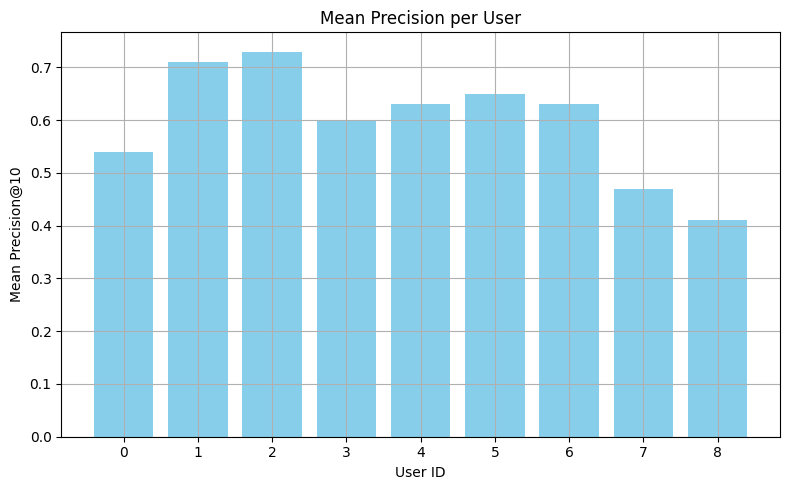

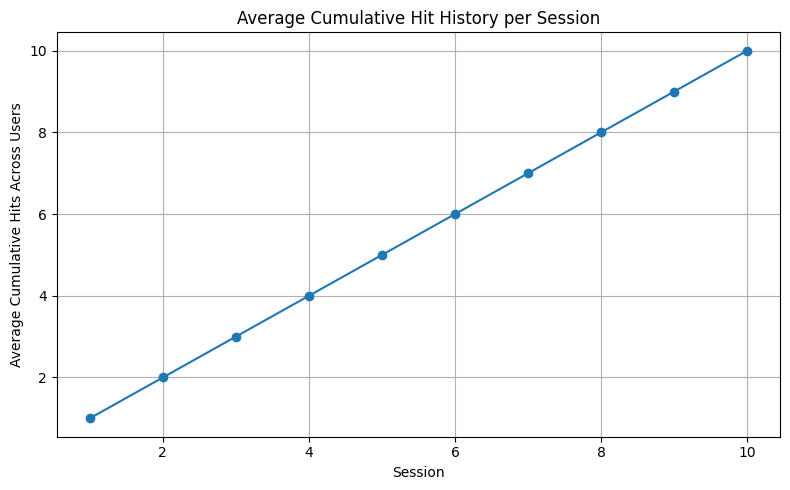

,Session,Users with ≥1 Hit,Total Users,Hit Rate@10,Temporal Hit Rate
0,1,9,9,1.0,1.0
1,2,9,9,1.0,1.0
2,3,9,9,1.0,1.0
3,4,9,9,1.0,1.0
4,5,9,9,1.0,1.0
5,6,9,9,1.0,1.0
6,7,9,9,1.0,1.0
7,8,9,9,1.0,1.0
8,9,9,9,1.0,1.0
9,10,9,9,1.0,1.0


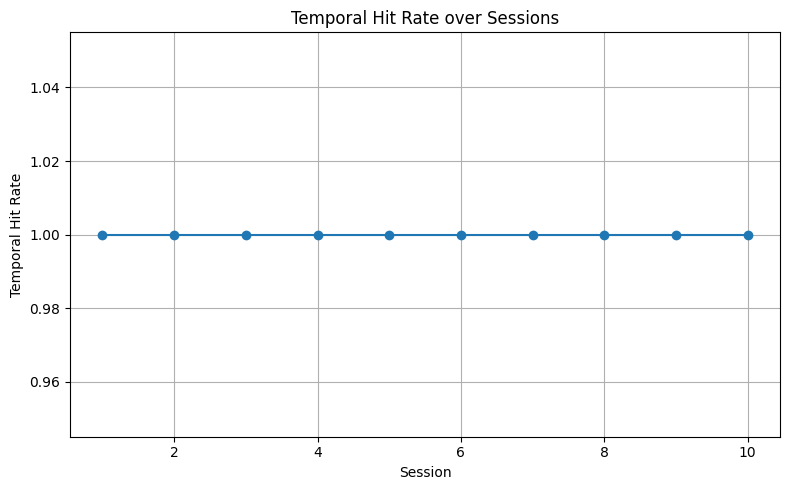

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def compute_precision_by_user(history_sessions, k=5):
    user_precisions = {}
    for session in history_sessions:
        for user, clicks in session.items():
            top_k_clicks = clicks[:k]
            precision = sum(top_k_clicks) / k
            if user not in user_precisions:
                user_precisions[user] = []
            user_precisions[user].append(precision)

    # Compute mean precision and cumulative hit rate
    summary = {
        "User": [],
        "Precision per Session": [],
        "Mean Precision": [],
        "Cumulative Hit History": []
    }
    for user, values in user_precisions.items():
        summary["User"].append(user)
        summary["Precision per Session"].append(values)
        summary["Mean Precision"].append(np.mean(values))
        cumulative_gt_zero = []
        count = 0
        for x in values:
            if x > 0:
                count += 1
            cumulative_gt_zero.append(count)
        summary["Cumulative Hit History"].append(cumulative_gt_zero)
    df = pd.DataFrame(summary)

   

    display(df)
    print(f"Mean Precision@{k} for all Users: {df['Mean Precision'].mean():.4f}")

    # Bar chart of mean precision per user
    plt.figure(figsize=(8, 5))
    plt.bar(df["User"], df["Mean Precision"], color='skyblue')
    plt.xlabel("User ID")
    plt.ylabel(f"Mean Precision@{k}")
    plt.title("Mean Precision per User")
    plt.xticks(df["User"])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    max_len = max(len(row["Cumulative Hit History"]) for _, row in df.iterrows())
    padded = np.zeros((len(df), max_len))

    for i, row in df.iterrows():
        padded[i, :len(row["Cumulative Hit History"])] = row["Cumulative Hit History"]

    average_cumulative_per_session = padded.mean(axis=0)

    # Plotting average cumulative hit history
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_len + 1), average_cumulative_per_session, marker='o')
    plt.xlabel("Session")
    plt.ylabel("Average Cumulative Hits Across Users")
    plt.title("Average Cumulative Hit History per Session")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df

def compute_hit_rate_with_plot(history_sessions, k=5):
    hit_rates = []
    cumulative_hit_count = 0
    clicked_user_counts = []

    for session in history_sessions:
        num_users = len(session)
        clicked_users = sum(any(session[user][j] for j in range(k)) for user in session)
        hit_rate = clicked_users / num_users
        hit_rates.append(hit_rate)
        clicked_user_counts.append(clicked_users)
        if clicked_users > 0:
            cumulative_hit_count += 1

    cumulative_hit_rate = cumulative_hit_count / len(history_sessions)
    temporal_hit_curve = np.cumsum(hit_rates) / np.arange(1, len(hit_rates) + 1)



    # DataFrame for inspection
    df = pd.DataFrame({
        "Session": np.arange(1, len(hit_rates) + 1),
        "Users with ≥1 Hit": clicked_user_counts,
        "Total Users": [len(session) for session in history_sessions],
        f"Hit Rate@{k}": hit_rates,
        "Temporal Hit Rate": temporal_hit_curve
    })
    display(df)

      # Line plot for Temporal Hit Rate
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(1, len(hit_rates) + 1), temporal_hit_curve, marker='o', linestyle='-')
    plt.xlabel("Session")
    plt.ylabel("Temporal Hit Rate")
    plt.title("Temporal Hit Rate over Sessions")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return df

print('A2C')
# Run both
precision_df = compute_precision_by_user(history_for_all_sessions, K)
hit_rate_df = compute_hit_rate_with_plot(history_for_all_sessions, K)


## PPO

In [20]:
model2 = A2C.load("models/PPO150k_citation_recommender_baseline", env=env, device="cpu")

Wrapping the env in a DummyVecEnv.


In [21]:
reccommended_papers, history_for_all_sessions = simulate_user_clicks(model2)

0


/var/folders/_f/s0xx4_bj711c1h8k9b5vjhgm0000gn/T/ipykernel_87846/2435250870.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  action = int(action)


Final score: (0.6586089392255499 + 0.2733333333333333 + 0.9330808080808081) / 3 = 0.6216743602132304
user = 0 - action = 14056 - rating = 0.6216743602132304 - click = 1 - interact_num = 1 - reward = 1.2433487204264608
Final score: (0.39065513415431474 + 0 + 0) / 3 = 0.13021837805143824
user = 0 - action = 48196 - rating = 0.13021837805143824 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.6081035349917934 + 0.34 + 0.9166666666666667) / 3 = 0.6215900672194867
user = 0 - action = 17124 - rating = 0.6215900672194867 - click = 1 - interact_num = 1 - reward = 1.2431801344389735
Final score: (0.6588771906116719 + 0.22 + 0.928030303030303) / 3 = 0.6023024978806583
user = 0 - action = 15123 - rating = 0.6023024978806583 - click = 1 - interact_num = 1 - reward = 1.2046049957613165
Final score: (0.5910747487876291 + 0 + 0) / 3 = 0.19702491626254304
user = 0 - action = 26975 - rating = 0.19702491626254304 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.65199303342386

In [23]:
reccommended_papers

[{0: (14056, 48196, 17124, 15123, 26975, 46678, 307, 40389, 18237, 35362),
  1: (11470, 30682, 30892, 24834, 47480, 15762, 23843, 36225, 45347, 48115),
  2: (39727, 373, 21699, 13089, 1030, 29025, 47139, 48642, 8632, 23057),
  3: (7504, 31623, 25064, 31328, 48858, 9293, 4687, 31357, 32528, 47660),
  4: (41634, 15111, 9912, 13471, 19071, 37765, 31338, 21370, 2482, 26339),
  5: (791, 13234, 17798, 40938, 27697, 19176, 16646, 11164, 41455, 43224),
  6: (15969, 44412, 10561, 23050, 11200, 9312, 41902, 40139, 41477, 32927),
  7: (26157, 11232, 18482, 18912, 31916, 26269, 33829, 24966, 26519, 12149),
  8: (48459, 20456, 42630, 12259, 7781, 16145, 16910, 9220, 32611, 42308)},
 {0: (42491, 13620, 42207, 49729, 25295, 7935, 30179, 6058, 10809, 8503),
  1: (47779, 43687, 12040, 27801, 17157, 23220, 47882, 29110, 14049, 20794),
  2: (17343, 23498, 17897, 17454, 36171, 17786, 8187, 15800, 34116, 16390),
  3: (12289, 45025, 30293, 4488, 7990, 8800, 27513, 36242, 8689, 15553),
  4: (24368, 8827, 391

PPO


,User,Precision per Session,Mean Precision,Cumulative Hit History
0,0,"[0.6, 0.6, 0.5, 0.6, 0.6, 0.5, 0.6, 0.7, 0.4, ...",0.55,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,1,"[0.4, 0.8, 0.5, 0.4, 0.3, 0.8, 0.8, 0.7, 1.0, ...",0.65,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
2,2,"[0.8, 0.8, 1.0, 0.7, 0.8, 0.6, 0.8, 0.8, 0.7, ...",0.77,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
3,3,"[0.6, 0.6, 0.7, 0.8, 0.7, 0.3, 0.6, 0.6, 0.5, ...",0.59,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
4,4,"[0.8, 0.6, 0.8, 0.5, 0.7, 0.8, 0.7, 0.7, 0.8, ...",0.70,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
5,5,"[0.9, 0.9, 0.8, 0.9, 0.4, 0.9, 0.6, 0.7, 0.7, ...",0.75,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
6,6,"[0.4, 0.7, 0.4, 0.4, 0.6, 0.6, 0.8, 0.6, 0.7, ...",0.58,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
7,7,"[0.4, 0.8, 0.4, 0.5, 0.5, 0.3, 0.4, 0.4, 0.5, ...",0.48,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
8,8,"[0.5, 0.4, 0.3, 0.2, 0.6, 0.5, 0.4, 0.6, 0.3, ...",0.39,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


Mean Precision@10 for all Users: 0.6067


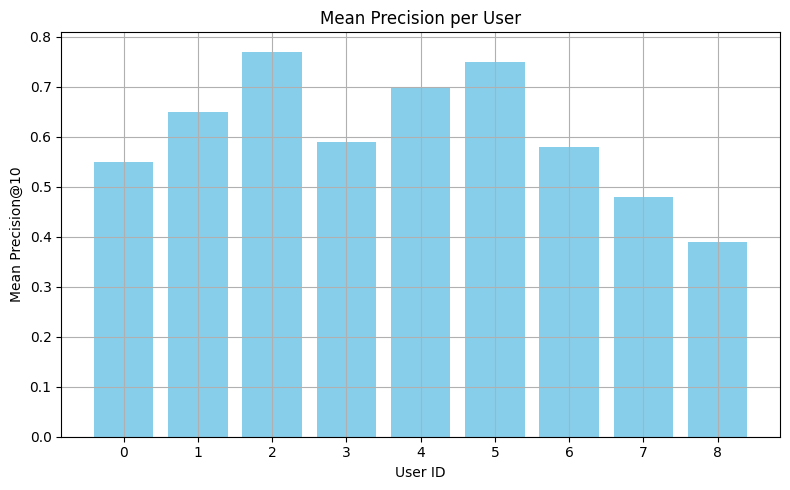

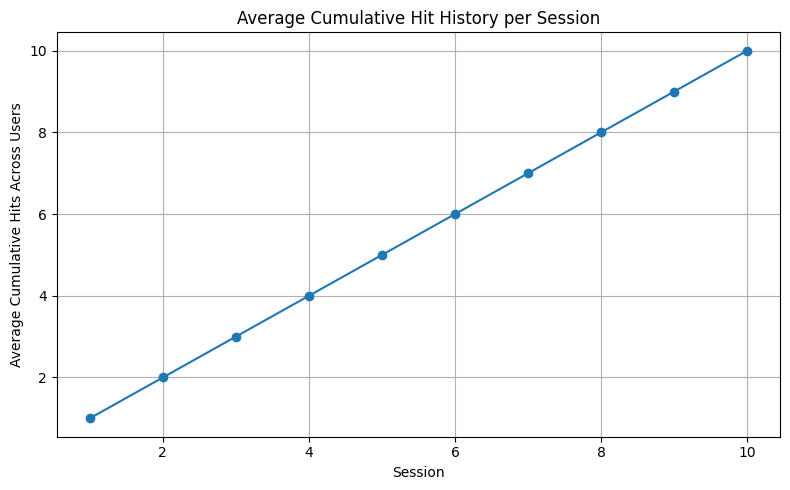

,Session,Users with ≥1 Hit,Total Users,Hit Rate@10,Temporal Hit Rate
0,1,9,9,1.0,1.0
1,2,9,9,1.0,1.0
2,3,9,9,1.0,1.0
3,4,9,9,1.0,1.0
4,5,9,9,1.0,1.0
5,6,9,9,1.0,1.0
6,7,9,9,1.0,1.0
7,8,9,9,1.0,1.0
8,9,9,9,1.0,1.0
9,10,9,9,1.0,1.0


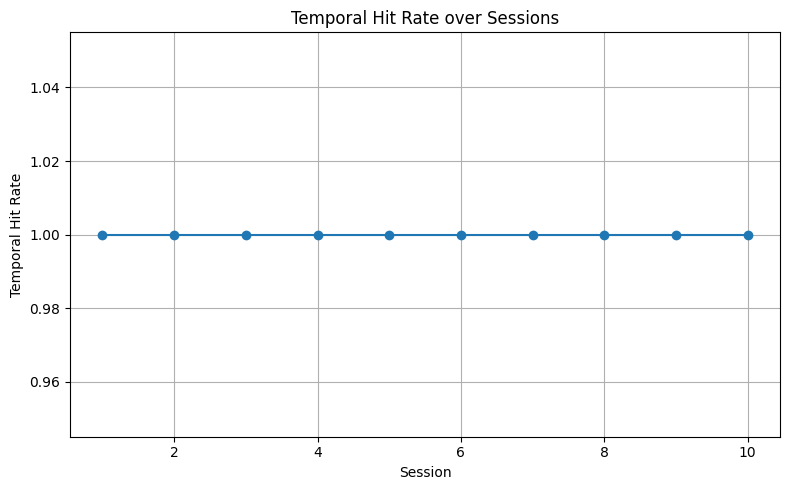

In [22]:
print('PPO')
# Run both
precision_df = compute_precision_by_user(history_for_all_sessions, K)
hit_rate_df = compute_hit_rate_with_plot(history_for_all_sessions, K)